# RoCOCO CLIP Retrieval Analysis

Results table: R@1, RSMS, DropRate across Baseline / Isotropic / Manifold smoothing
for all 5 annotation types (Base COCO, Danger, Same, Diff, Rand).

In [8]:
import os, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 11,
    'axes.labelsize': 12, 'axes.titlesize': 13,
    'legend.fontsize': 9, 'figure.dpi': 120,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})

C = {
    'baseline':  '#636363',
    'isotropic': '#2166ac',
    'manifold':  '#f5c518',
    'manifold_scaled':  '#f5c518',
}
LS = {'baseline': ':', 'isotropic': '--', 'manifold': '-', 'manifold_scaled': '-'}

REPO_ROOT = Path(os.path.abspath('..'))
OUT_DIR   = REPO_ROOT / 'output' / 'rococo'

MODES     = ['baseline', 'isotropic', 'manifold']
ANN_STEMS = ['coco_karpathy_test', 'danger', 'same_concept', 'diff_concept', 'rand_voca']
ANN_LABELS = {'coco_karpathy_test': 'Base COCO', 'danger': 'Danger',
               'same_concept': 'Same', 'diff_concept': 'Diff', 'rand_voca': 'Rand'}

def load_json(p):
    return json.loads(Path(p).read_text()) if Path(p).exists() else None

def sigma_tag(s): return f"sigma_{s:.2f}".replace('.','_')

# Load all results — both flat (no sigma subdir) and sigma-sweep subdir
results = {}   # (mode, ann, sigma) → metrics dict

for mode in MODES:
    mode_dir = OUT_DIR / mode
    if not mode_dir.exists(): continue

    # sigma subdirs: output/rococo/{mode}/sigma_X_XX/{ann}_metrics.json
    for sigma_dir in sorted(mode_dir.glob("sigma_*")):
        sigma_val = float(sigma_dir.name.replace("sigma_","").replace("_","."))
        for ann in ANN_STEMS:
            m = load_json(sigma_dir / f"{ann}_metrics.json")
            if m:
                results[(mode, ann, sigma_val)] = m

    # flat (no sigma subdir): output/rococo/{mode}/{ann}_metrics.json  (single sigma)
    for ann in ANN_STEMS:
        m = load_json(mode_dir / f"{ann}_metrics.json")
        if m:
            sigma_val = m.get("smoothing", {}).get("sigma", 0.0)
            results[(mode, ann, sigma_val)] = m

sigmas_found = sorted(set(s for _,_,s in results.keys()))
print(f"Loaded {len(results)} results")
print(f"Modes:  {MODES}")
print(f"Sigmas: {sigmas_found}")

Loaded 85 results
Modes:  ['baseline', 'isotropic', 'manifold']
Sigmas: [0.0, 0.02, 0.05, 0.07, 0.1, 0.2, 0.5, 0.7, 1.0]


##  Main Results Table

In [2]:
## 1. Baseline Table (sigma-independent)

clip_model = next((v.get('clip_model','?') for v in results.values()), '?')
print(f"CLIP model:       {clip_model}")
print(f"Sigmas evaluated: {sigmas_found}")

r1_base_coco = next(
    (results[('baseline','coco_karpathy_test',s)].get('R@1')
     for s in sigmas_found if ('baseline','coco_karpathy_test',s) in results),
    None
)
print(f"R@1_COCO (baseline clean): {r1_base_coco}%")

base_rows = []
for ann in ANN_STEMS:
    m    = next((results[('baseline',ann,s)] for s in sigmas_found
                  if ('baseline',ann,s) in results), {})
    r1   = m.get('R@1',  None)
    rsms = m.get('RSMS', None)
    drop = round((r1_base_coco - r1) / r1_base_coco * 100, 1) \
           if (r1_base_coco and r1 and ann != 'coco_karpathy_test') else None
    base_rows.append({
        'Dataset':  ANN_LABELS[ann],
        'R@1':      r1,
        'R@5':      m.get('R@5',  None),
        'R@10':     m.get('R@10', None),
        'RSMS':     rsms,
        'Drop%':    drop,
    })

base_df = pd.DataFrame(base_rows).set_index('Dataset')

def safe_fmt(v):
    try:
        if v is None or (isinstance(v, float) and np.isnan(v)):
            return '–'
        return f'{float(v):.1f}'
    except Exception:
        return '–'

display(base_df.style
        .format(safe_fmt)
        .background_gradient(subset=['R@1'], cmap='Blues', vmin=0, vmax=100)
        .background_gradient(subset=['RSMS'], cmap='Reds_r', vmin=0, vmax=40)
        .background_gradient(subset=['Drop%'], cmap='Reds', vmin=0, vmax=30)
        .set_caption(
            f'Baseline — no smoothing  |  CLIP: {clip_model}\n'
            f'Drop% = (R@1_COCO − R@1_ann) / R@1_COCO  [R@1_COCO = {r1_base_coco}%]'))

CLIP model:       ViT-B/32
Sigmas evaluated: [0.0, 0.02, 0.05, 0.07, 0.1, 0.2, 0.5, 0.7, 1.0]
R@1_COCO (baseline clean): 50.16%


,R@1,R@5,R@10,RSMS,Drop%
Dataset,,,,,
Base COCO,50.2,75.0,83.5,–,–
Danger,41.3,68.9,77.9,23.0,17.7
Same,39.0,67.8,77.7,29.3,22.2
Diff,40.3,68.5,78.2,26.5,19.7
Rand,39.2,67.8,77.5,28.5,21.9


In [9]:
## 2. Combined table — CLIP baseline + ISO + Mani
# Rows: (σ, Mode)   Cols: ann × metric
#
# Drop% = (R@1_clean_COCO_baseline − R@1_method_ann) / R@1_clean_COCO_baseline
#
# Denominator is ALWAYS the clean unsmoothed CLIP R@1 on coco_karpathy_test.
# This follows the RoCOCO paper convention — all methods compared against
# the same clean CLIP baseline, not against their own smoothed COCO performance.

def safe_fmt(v):
    try:
        if v is None or (isinstance(v, float) and np.isnan(v)):
            return '–'
        return f'{float(v):.1f}'
    except Exception:
        return '–'

# Fixed denominator: clean baseline CLIP R@1 on coco_karpathy_test
r1_clean_coco = next(
    (results[('baseline','coco_karpathy_test',s)].get('R@1')
     for s in sigmas_found if ('baseline','coco_karpathy_test',s) in results), None)
print(f"R@1_clean_COCO (fixed denominator for all Drop%): {r1_clean_coco}%")

mode_sigmas = sorted(set(s for m,a,s in results if m in ('isotropic','manifold')))

col_tuples = [(ANN_LABELS[a], metric)
              for a in ANN_STEMS
              for metric in ['R@1', 'RSMS', 'Drop%']]

rows      = []
row_index = []

# ── Baseline CLIP row ─────────────────────────────────────────────────────────
row = []
for ann in ANN_STEMS:
    m    = next((results[('baseline',ann,s)] for s in sigmas_found
                  if ('baseline',ann,s) in results), {})
    r1   = m.get('R@1',  None)
    rsms = m.get('RSMS', None)
    drop = round((r1_clean_coco - r1) / r1_clean_coco * 100, 1) \
           if (r1_clean_coco and r1 and ann != 'coco_karpathy_test') else None
    row += [r1, rsms, drop]
rows.append(row)
row_index.append(('–', 'CLIP'))

# ── ISO + Mani rows per sigma ─────────────────────────────────────────────────
mode_map = {'ISO': 'isotropic', 'Mani': 'manifold'}
for s in mode_sigmas:
    for mode_short, mode_key in mode_map.items():
        row = []
        for ann in ANN_STEMS:
            m    = results.get((mode_key, ann, s), {})
            r1   = m.get('R@1',  None)
            rsms = m.get('RSMS', None)
            # Drop% always uses clean CLIP baseline as denominator
            drop = round((r1_clean_coco - r1) / r1_clean_coco * 100, 1) \
                   if (r1_clean_coco and r1 and ann != 'coco_karpathy_test') else None
            row += [r1, rsms, drop]
        rows.append(row)
        row_index.append((f'σ={s}', mode_short))

cols = pd.MultiIndex.from_tuples(col_tuples)
idx  = pd.MultiIndex.from_tuples(row_index, names=['σ', 'Mode'])
df_combined = pd.DataFrame(rows, index=idx, columns=cols)

r1_cols   = [(ANN_LABELS[a], 'R@1')   for a in ANN_STEMS if (ANN_LABELS[a],'R@1')   in cols]
rsms_cols = [(ANN_LABELS[a], 'RSMS')  for a in ANN_STEMS if (ANN_LABELS[a],'RSMS')  in cols]
drop_cols = [(ANN_LABELS[a], 'Drop%') for a in ANN_STEMS if (ANN_LABELS[a],'Drop%') in cols]

clip_model = next((v.get('clip_model','?') for v in results.values()), '?')

styler = df_combined.style.format(safe_fmt)
if r1_cols:
    styler = styler.background_gradient(subset=r1_cols,   cmap='Blues',  vmin=0, vmax=100)
if rsms_cols:
    styler = styler.background_gradient(subset=rsms_cols, cmap='Reds_r', vmin=0, vmax=40)
if drop_cols:
    styler = styler.background_gradient(subset=drop_cols, cmap='Reds',   vmin=0, vmax=30)
styler = styler.set_caption(
    f'CLIP baseline + ISO + Manifold | model: {clip_model}\n'
    f'Drop% = (R@1_clean_COCO − R@1_method_ann) / R@1_clean_COCO  '
    f'[fixed denominator: {r1_clean_coco}%]'
).set_table_styles([
    {'selector': 'th',            'props': [('font-size','8pt'), ('text-align','center')]},
    {'selector': 'th.row_heading','props': [('font-size','8pt'), ('text-align','left')]},
])
display(styler)

R@1_clean_COCO (fixed denominator for all Drop%): 50.16%


In [10]:
from pathlib import Path
import pandas as pd
import numpy as np

outdir = Path("rococo_tables")
outdir.mkdir(exist_ok=True)

# Save CSV
df_combined.to_csv(outdir / "rococo_clip_iso_mani_unscaled.csv")

def fmt(x):
    if pd.isna(x):
        return "--"
    return f"{x:.2f}"

lines = []

lines.append(r"\begin{table*}[t]")
lines.append(r"\centering")
lines.append(
    rf"\caption{{Image-to-Text retrieval robustness on RoCOCO using CLIP {clip_model} "
    r"with isotropic and manifold smoothing.}}")
lines.append(r"\label{tab:rococo_smoothing}")
lines.append(r"\resizebox{\textwidth}{!}{")
lines.append(r"\begin{tabular}{ll|ccc|ccc|ccc|ccc|ccc}")
lines.append(r"\toprule")

lines.append(
r"& & \multicolumn{3}{c|}{Base COCO}"
r"& \multicolumn{3}{c|}{Danger}"
r"& \multicolumn{3}{c|}{Same-Concept}"
r"& \multicolumn{3}{c|}{Diff-Concept}"
r"& \multicolumn{3}{c}{Rand-Voca} \\"
)

lines.append(r"\cmidrule(lr){3-5}")
lines.append(r"\cmidrule(lr){6-8}")
lines.append(r"\cmidrule(lr){9-11}")
lines.append(r"\cmidrule(lr){12-14}")
lines.append(r"\cmidrule(lr){15-17}")

lines.append(
r"$\sigma$ & Mode"
r"& R@1 & RSMS & Drop\%"
r"& R@1 & RSMS & Drop\%"
r"& R@1 & RSMS & Drop\%"
r"& R@1 & RSMS & Drop\%"
r"& R@1 & RSMS & Drop\% \\"
)

lines.append(r"\midrule")

# ---------------- Baseline ----------------
clip = df_combined.loc[("–","CLIP")]

vals = []
for ann in ANN_LABELS.values():
    vals += [fmt(clip[(ann,"R@1")]),
             "--",
             fmt(clip[(ann,"Drop%")])]

lines.append(
"-- & CLIP & " + " & ".join(vals) + r" \\"
)

lines.append(r"\addlinespace[2mm]")

# ---------------- ISO / Mani ----------------
sigmas = sorted(
    s for s in df_combined.index.get_level_values(0).unique()
    if s != "–"
)

for sigma in sigmas:

    sigma_tex = sigma.replace("σ=", r"$\sigma=") + "$"

    lines.append(
        rf"\multirow{{2}}{{*}}{{{sigma_tex}}}"
    )

    for i, mode in enumerate(["ISO","Mani"]):

        row = df_combined.loc[(sigma, mode)]

        vals = []

        for ann in ANN_LABELS.values():

            vals += [
                fmt(row[(ann,"R@1")]),
                "--" if pd.isna(row[(ann,"RSMS")]) else fmt(row[(ann,"RSMS")]),
                "--" if pd.isna(row[(ann,"Drop%")]) else fmt(row[(ann,"Drop%")]),
            ]

        prefix = "& " if i else "& "

        lines[-1] += prefix + mode + " & " + " & ".join(vals) + r" \\"

        if i == 0:
            lines.append("")

    lines.append(r"\addlinespace[2mm]")

lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(r"}")
lines.append(r"\end{table*}")

tex = "\n".join(lines)

(outdir/"rococo_clip_iso_mani_unscaled.tex").write_text(tex)

print(tex)

\begin{table*}[t]
\centering
\caption{Image-to-Text retrieval robustness on RoCOCO using CLIP ViT-B/32 with isotropic and manifold smoothing.}}
\label{tab:rococo_smoothing}
\resizebox{\textwidth}{!}{
\begin{tabular}{ll|ccc|ccc|ccc|ccc|ccc}
\toprule
& & \multicolumn{3}{c|}{Base COCO}& \multicolumn{3}{c|}{Danger}& \multicolumn{3}{c|}{Same-Concept}& \multicolumn{3}{c|}{Diff-Concept}& \multicolumn{3}{c}{Rand-Voca} \\
\cmidrule(lr){3-5}
\cmidrule(lr){6-8}
\cmidrule(lr){9-11}
\cmidrule(lr){12-14}
\cmidrule(lr){15-17}
$\sigma$ & Mode& R@1 & RSMS & Drop\%& R@1 & RSMS & Drop\%& R@1 & RSMS & Drop\%& R@1 & RSMS & Drop\%& R@1 & RSMS & Drop\% \\
\midrule
-- & CLIP & 50.16 & -- & -- & 41.26 & -- & 17.70 & 39.00 & -- & 22.20 & 40.28 & -- & 19.70 & 39.18 & -- & 21.90 \\
\addlinespacem]
\multirow{2}{*}{$\sigma=0.02$}& ISO & 43.30 & -- & -- & 35.24 & 26.46 & 29.70 & 32.38 & 34.62 & 35.40 & 33.40 & 33.54 & 33.40 & 33.16 & 33.52 & 33.90 \\
& Mani & 50.16 & -- & -- & 41.26 & 22.98 & 17.70 & 39.00 & 29.12 &

# Sigma Sweep 

/tmp/ipykernel_874005/132746902.py:10: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(sigs, r1s, 'o-', color=C[mode], ls=LS[mode], lw=2, label=mode.title())


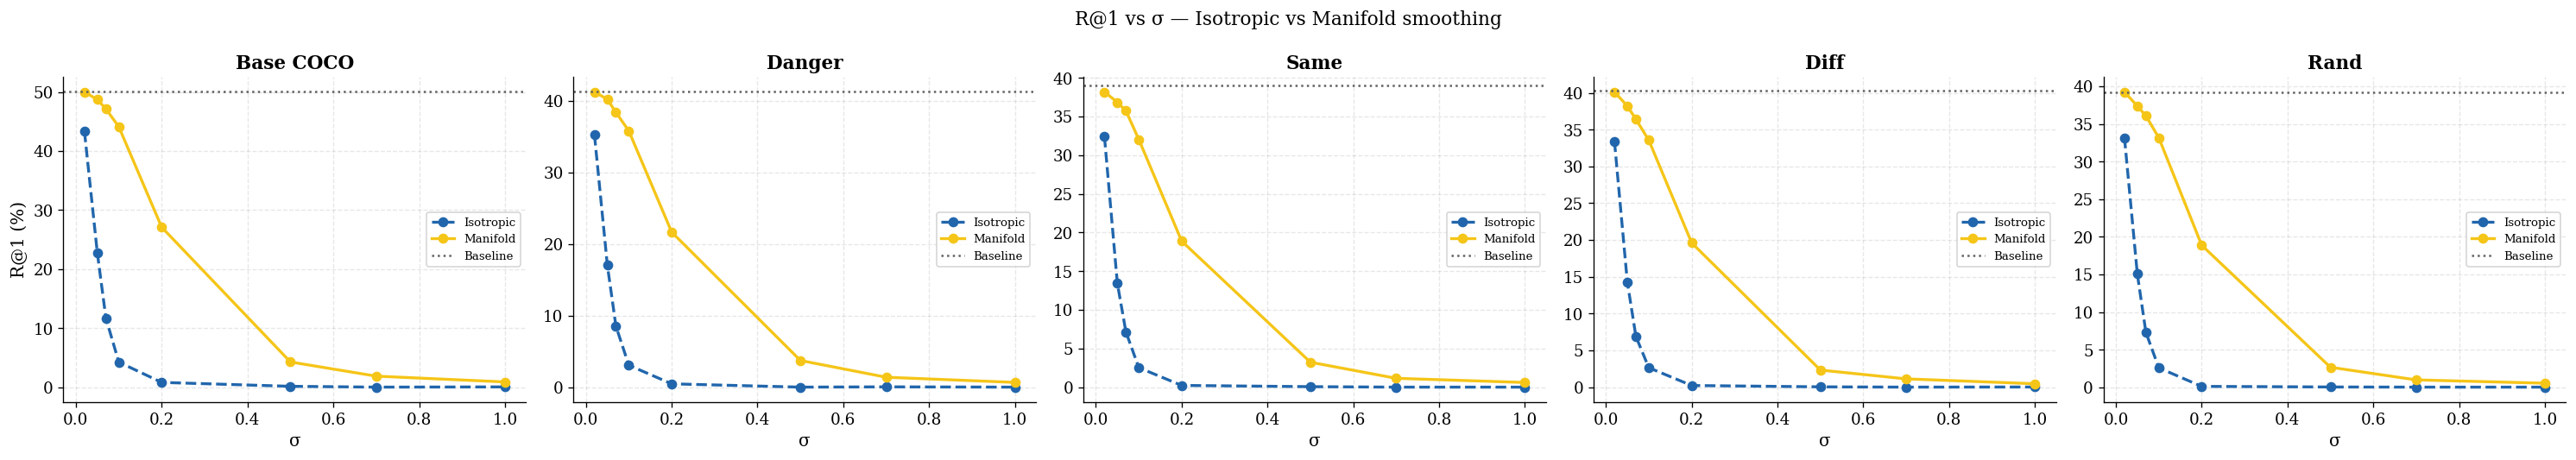

/tmp/ipykernel_874005/132746902.py:36: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(sigs, rsms, 'o-', color=C[mode], ls=LS[mode], lw=2, label=mode.title())


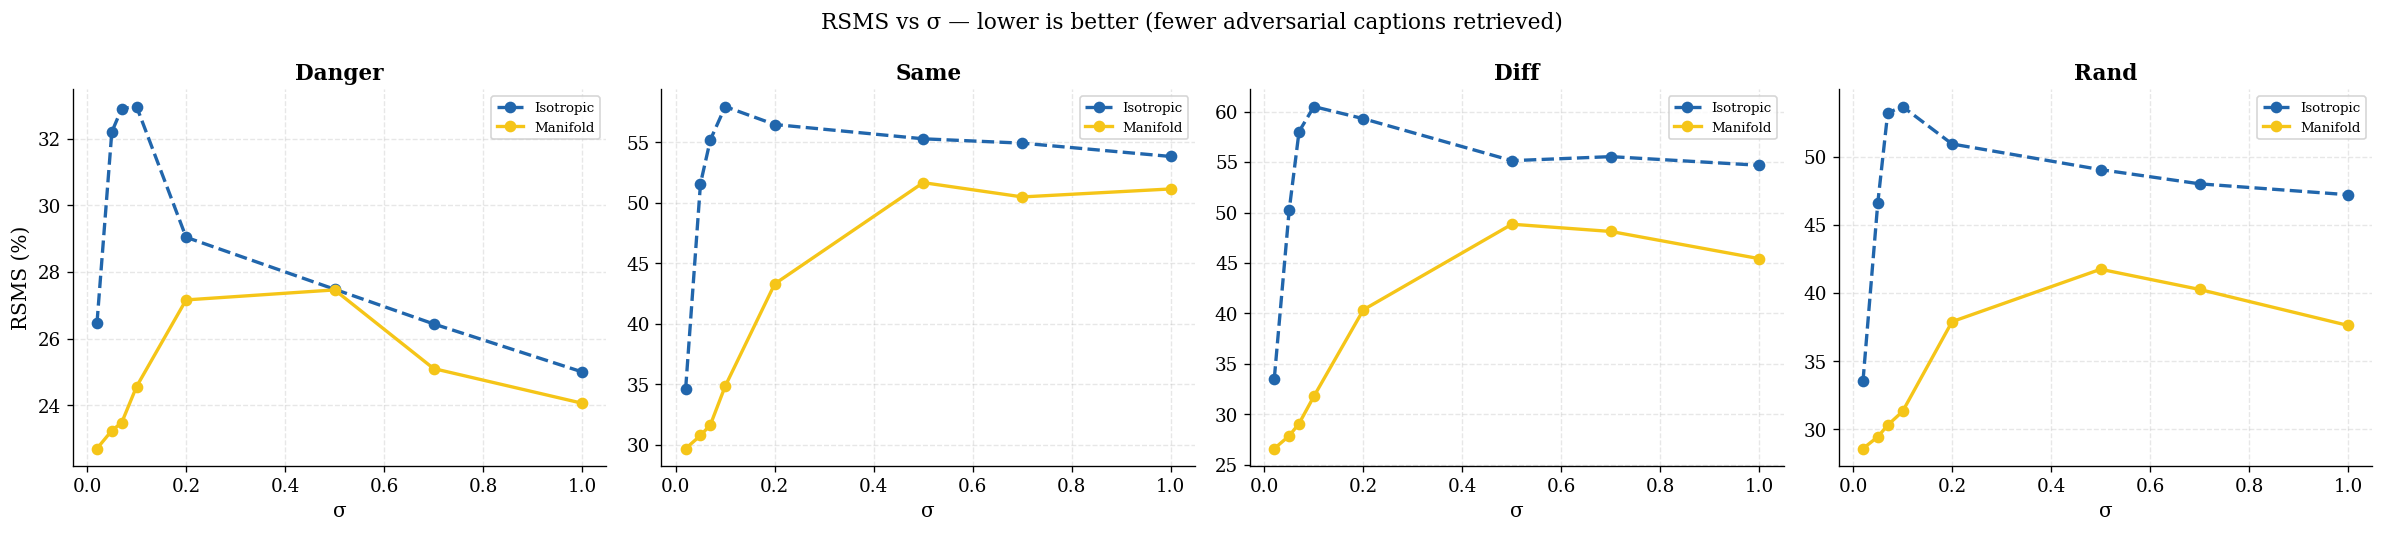

In [4]:
## R@1 vs σ for each annotation set (ISO vs Manifold)
if sigmas_found:
    fig, axes = plt.subplots(1, len(ANN_STEMS), figsize=(5*len(ANN_STEMS), 4.5),
                             sharey=False, squeeze=False)
    for j, ann in enumerate(ANN_STEMS):
        ax = axes[0, j]
        for mode in ['isotropic', 'manifold']:
            sigs = sorted(s for m,a,s in results if m==mode and a==ann)
            r1s  = [results[(mode,ann,s)].get('R@1', np.nan) for s in sigs]
            ax.plot(sigs, r1s, 'o-', color=C[mode], ls=LS[mode], lw=2, label=mode.title())
        # Baseline (sigma-independent) — horizontal line at best sigma
        base_vals = [results[('baseline',ann,s)].get('R@1') for s in sigmas_found
                     if ('baseline',ann,s) in results]
        if base_vals:
            ax.axhline(max(v for v in base_vals if v), color=C['baseline'],
                       lw=1.5, ls=':', label='Baseline')
        ax.set_title(ANN_LABELS[ann], fontweight='bold')
        ax.set_xlabel('σ')
        ax.set_ylabel('R@1 (%)' if j==0 else '')
        ax.legend(fontsize=8)

    fig.suptitle('R@1 vs σ — Isotropic vs Manifold smoothing', fontsize=13)
    plt.tight_layout()
    plt.savefig('fig_rococo_sigma_sweep.pdf', bbox_inches='tight')
    plt.show()

    ## RSMS vs σ (adversarial annotations only)
    adv_anns = [a for a in ANN_STEMS if a != 'coco_karpathy_test']
    fig2, axes2 = plt.subplots(1, len(adv_anns), figsize=(5*len(adv_anns), 4.5),
                               sharey=False, squeeze=False)
    for j, ann in enumerate(adv_anns):
        ax = axes2[0, j]
        for mode in ['isotropic', 'manifold']:
            sigs = sorted(s for m,a,s in results if m==mode and a==ann)
            rsms = [results[(mode,ann,s)].get('RSMS', np.nan) for s in sigs]
            ax.plot(sigs, rsms, 'o-', color=C[mode], ls=LS[mode], lw=2, label=mode.title())
        ax.set_title(ANN_LABELS[ann], fontweight='bold')
        ax.set_xlabel('σ')
        ax.set_ylabel('RSMS (%)' if j==0 else '')
        ax.legend(fontsize=8)
    fig2.suptitle('RSMS vs σ — lower is better (fewer adversarial captions retrieved)', fontsize=13)
    plt.tight_layout()
    plt.savefig('fig_rococo_rsms_sigma.pdf', bbox_inches='tight')
    plt.show()
else:
    print('No sigma sweep results yet.')

In [5]:
## RSMS@1–5 table — ISO vs Mani, per annotation × sigma
# Rows: sigma   Cols: (ISO | Mani) × (RSMS@1, @2, @3, @4, @5)
# RSMS@k = % images where adversarial caption is at EXACTLY rank k

ADV_ANNS = [a for a in ANN_STEMS if a != 'coco_karpathy_test']
RSMS_KS  = [1, 2, 3, 4, 5]

def safe_fmt(v):
    try:
        if v is None or (isinstance(v, float) and np.isnan(v)):
            return '–'
        return f'{float(v):.1f}'
    except Exception:
        return '–'

mode_sigmas = sorted(set(s for m,a,s in results if m in ('isotropic','manifold_scaled')))
mode_map    = {'ISO': 'isotropic', 'Mani': 'manifold_scaled'}

for ann in ADV_ANNS:
    col_tuples = [(mode_short, f'RSMS@{k}')
                  for mode_short in ['ISO', 'Mani']
                  for k in RSMS_KS]
    cols = pd.MultiIndex.from_tuples(col_tuples)

    rows, row_idx = [], []
    for s in mode_sigmas:
        row = []
        for mode_short, mode_key in mode_map.items():
            m = results.get((mode_key, ann, s), {})
            for k in RSMS_KS:
                # Use RSMS@k if available (new runs), else fall back to RSMS for k=1
                val = m.get(f'RSMS@{k}', m.get('RSMS') if k == 1 else None)
                row.append(val)
        rows.append(row)
        row_idx.append(f'σ={s}')

    df = pd.DataFrame(rows, index=row_idx, columns=cols)
    df.index.name = 'σ'

    rsms_cols = [c for c in cols]
    styler = (df.style
               .format(safe_fmt)
               .background_gradient(subset=rsms_cols, cmap='Reds', vmin=0, vmax=30)
               .set_caption(f'RSMS@k — {ANN_LABELS[ann]}  |  exactly at rank k')
               .set_table_styles([
                   {'selector': 'th', 'props': [('font-size','8pt'),('text-align','center')]},
               ]))
    display(styler)

In [6]:
from pathlib import Path

outdir = Path("rsms_tables")
outdir.mkdir(exist_ok=True)

# ---------- CSV ----------
csv_path = outdir / f"{ann}_rsms_table.csv"
df.to_csv(csv_path)

# ---------- LaTeX ----------
latex = df.to_latex(
    escape=False,
    multicolumn=True,
    multicolumn_format='c',
    float_format=lambda x: f"{x:.1f}" if pd.notna(x) else "--",
    caption=f"{ANN_LABELS[ann]}",
    label=f"tab:rsms_{ann}"
)

latex = f"""
\\begin{{table}}[ht]
\\centering
\\begin{{adjustbox}}{{max width=\\textwidth}}
{latex}
\\end{{adjustbox}}
\\end{{table}}
"""

tex_path = outdir / f"{ann}_rsms_table.tex"
tex_path.write_text(latex)

print(f"Saved: {csv_path}")
print(f"Saved: {tex_path}")

Saved: rsms_tables/rand_voca_rsms_table.csv
Saved: rsms_tables/rand_voca_rsms_table.tex


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

outdir = Path("rsms_tables")
outdir.mkdir(exist_ok=True)

ADV_ANNS = [a for a in ANN_STEMS if a != "coco_karpathy_test"]
RSMS_KS = [1, 2, 3, 4, 5]

mode_sigmas = sorted(set(s for m, a, s in results if m in ("isotropic", "manifold")))
mode_map = {"ISO": "isotropic", "Mani": "manifold"}

def latex_escape(s):
    return str(s).replace("_", r"\_")

for ann in ADV_ANNS:
    col_tuples = [
        (mode_short, f"RSMS@{k}")
        for mode_short in ["ISO", "Mani"]
        for k in RSMS_KS
    ]

    cols = pd.MultiIndex.from_tuples(col_tuples)

    rows, row_idx = [], []

    for s in mode_sigmas:
        row = []

        for mode_short, mode_key in mode_map.items():
            m = results.get((mode_key, ann, s), {})

            for k in RSMS_KS:
                val = m.get(f"RSMS@{k}", m.get("RSMS") if k == 1 else np.nan)
                row.append(val)

        rows.append(row)
        row_idx.append(f"$\\sigma={s}$")

    df = pd.DataFrame(rows, index=row_idx, columns=cols)
    df.index.name = "$\\sigma$"

    csv_path = outdir / f"{ann}_rsms_table.csv"
    df.to_csv(csv_path)

    tabular = df.to_latex(
        escape=False,
        multicolumn=True,
        multicolumn_format="c",
        float_format=lambda x: f"{x:.1f}" if pd.notna(x) else "--"
    )

    caption = (
        f"Comparison of isotropic and manifold smoothing using RSMS@k "
        f"on {latex_escape(ANN_LABELS[ann])}."
    )

    latex = f"""
\\begin{{table}}[ht]
\\centering
\\caption{{{caption}}}
\\label{{tab:rsms_{ann}}}
\\begin{{adjustbox}}{{max width=\\textwidth}}
{tabular}
\\end{{adjustbox}}
\\end{{table}}
"""

    tex_path = outdir / f"{ann}_rsms_table.tex"
    tex_path.write_text(latex)

    print(f"Saved: {csv_path}")
    print(f"Saved: {tex_path}")

Saved: rsms_tables/danger_rsms_table.csv
Saved: rsms_tables/danger_rsms_table.tex
Saved: rsms_tables/same_concept_rsms_table.csv
Saved: rsms_tables/same_concept_rsms_table.tex
Saved: rsms_tables/diff_concept_rsms_table.csv
Saved: rsms_tables/diff_concept_rsms_table.tex
Saved: rsms_tables/rand_voca_rsms_table.csv
Saved: rsms_tables/rand_voca_rsms_table.tex


In [7]:
## Manifold geometry — eigenvalue spectrum & alpha amplification
# Uses the ACTUAL Annoy index (same as eval pipeline), NOT brute-force cosine kNN.
# Saved embeddings are already L2-normalized (F.normalize in CLIPWrapper).

import torch, sys
sys.path.insert(0, str(REPO_ROOT))
from src.configs.rococo_clip_schema import load_rococo_config
from src.experiments.indexing.rococo_clip_images import build_rococo_clip_index
from src.smoothing.pca import fit_local_pca

CFG_PATH = REPO_ROOT / 'src/configs/experiments/rococo_clip_manifold.yaml'
KNN_K    = 500
N_ANCHORS = 20

cfg = load_rococo_config(str(CFG_PATH))
cfg.smoothing.knn_k = KNN_K

# Load embeddings — already L2-normalized when saved
cache = torch.load('/BS/dniazi_thesis/static00/rococo/clip_embeddings/image_embeddings.pt',
                   map_location='cpu')
embs  = cache['embeddings'].numpy().astype('float32')   # (5000, 512), norm=1
norms = np.linalg.norm(embs, axis=1)
print(f"Embeddings: {embs.shape}  |  L2 norms: mean={norms.mean():.4f}  min={norms.min():.4f}  max={norms.max():.4f}")
print(f"  → {'Already on unit sphere ✓' if abs(norms.mean()-1)<0.01 else 'NOT normalized!'}")

# Load Annoy index (same one used in eval)
pixel_index = build_rococo_clip_index(cfg, rebuild=False)
print(f"Annoy index: {pixel_index.index.get_n_items():,} vectors  metric={cfg.index.metric}")

# Sample anchors
rng     = np.random.default_rng(42)
anchors = rng.choice(len(embs), N_ANCHORS, replace=False)

all_evals, lambda_maxs = [], []
for ai in anchors:
    anchor  = embs[ai]
    nn_ids  = pixel_index.index.get_nns_by_vector(anchor.tolist(), KNN_K+1, include_distances=False)
    nn_ids  = [n for n in nn_ids if n != ai][:KNN_K]
    neighbours = embs[nn_ids]   # (KNN_K, 512)

    pca = fit_local_pca(neighbours)
    all_evals.append(pca.evals)
    lambda_maxs.append(float(pca.evals[0]))

all_evals   = np.array(all_evals)
lambda_maxs = np.array(lambda_maxs)
print(f"\nlambda_max — mean={lambda_maxs.mean():.5f}  min={lambda_maxs.min():.5f}  max={lambda_maxs.max():.5f}")
for s in [0.02, 0.05, 0.1, 0.2]:
    alpha = s / np.sqrt(lambda_maxs.mean())
    print(f"  sigma={s}  →  alpha={alpha:.3f}  ({alpha/s:.1f}× amplification)")

# ── Figure ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Panel 1: eigenvalue spectrum
ax = axes[0]
mean_ev = all_evals.mean(axis=0)[:50]
ax.plot(range(1, len(mean_ev)+1), mean_ev, 'o-', ms=3, lw=1.5, color='#2166ac')
ax.fill_between(range(1, len(mean_ev)+1),
                all_evals.min(axis=0)[:50], all_evals.max(axis=0)[:50],
                alpha=0.2, color='#2166ac', label='min–max range')
ax.set_xlabel('PC index'); ax.set_ylabel('Eigenvalue λ')
ax.set_title(f'Eigenvalue spectrum\n(Annoy index, k={KNN_K} neighbours)')
ax.set_yscale('log'); ax.legend(fontsize=8)

# Panel 2: neighbourhood ellipse for one anchor
ax = axes[1]
ai0    = anchors[0]
anchor = embs[ai0]
nn_ids = pixel_index.index.get_nns_by_vector(anchor.tolist(), KNN_K+1, include_distances=False)
nn_ids = [n for n in nn_ids if n != ai0][:KNN_K]
neighbours = embs[nn_ids]
pca0   = fit_local_pca(neighbours)
centered = neighbours - pca0.mean
proj     = centered @ pca0.evecs[:, :2]
std1, std2 = np.sqrt(pca0.evals[0]), np.sqrt(pca0.evals[1])

ax.scatter(proj[:,0], proj[:,1], alpha=0.3, s=8, color='#2166ac', label='kNN neighbours')
ax.scatter(0, 0, color='red', s=60, zorder=5, label='anchor (centred)')
from matplotlib.patches import Ellipse as _Ell
ax.add_patch(_Ell((0,0), width=2*std1, height=2*std2,
                  edgecolor='#c0392b', facecolor='none', lw=2, label='1-std ellipse'))
ax.set_xlabel(f'PC1 (std={std1:.4f})'); ax.set_ylabel(f'PC2 (std={std2:.4f})')
ax.set_title('Neighbourhood shape — PC1 vs PC2'); ax.legend(fontsize=8); ax.set_aspect('equal')

# Panel 3: alpha amplification curve
ax = axes[2]
sig_arr   = np.linspace(0.005, 1.0, 200)
mean_lmax = lambda_maxs.mean()
ax.fill_between(sig_arr,
                sig_arr / np.sqrt(lambda_maxs.max()),
                sig_arr / np.sqrt(lambda_maxs.min()),
                alpha=0.15, color='#c0392b', label='range across anchors')
ax.plot(sig_arr, sig_arr / np.sqrt(mean_lmax), lw=2, color='#c0392b',
        label=f'alpha = σ/√λ_max  (mean λ_max={mean_lmax:.5f})')
ax.plot(sig_arr, sig_arr, lw=1.5, ls='--', color='#636363', label='alpha = σ (no amplification)')
ax.axhline(1.0, color='orange', lw=1, ls=':', label='alpha=1')
for s in [0.02, 0.05, 0.1, 0.2]:
    a = s / np.sqrt(mean_lmax)
    ax.annotate(f'σ={s}\nα={a:.1f}', xy=(s,a), xytext=(s+0.02, a+0.3),
                fontsize=7, color='#c0392b',
                arrowprops=dict(arrowstyle='->', color='#c0392b', lw=0.8))
ax.set_xlabel('σ'); ax.set_ylabel('alpha (effective noise std)')
ax.set_title('Noise amplification\nalpha = σ / √λ_max  ≫  σ'); ax.legend(fontsize=8)

fig.suptitle('CLIP Manifold Geometry (Annoy index, unit-sphere embeddings)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_clip_manifold_geometry.pdf', bbox_inches='tight')
plt.show()

KeyboardInterrupt: 